---
##  CELDA 1 — Importar librerías
Cargamos todas las herramientas necesarias para el análisis.

In [9]:
import pandas as pd          # manejo de tablas de datos
import numpy as np           # cálculos matemáticos
import matplotlib.pyplot as plt  # gráficos
import matplotlib.ticker as ticker
from scipy import stats      # estadística avanzada (KDE)
import re                    # expresiones regulares
import warnings
warnings.filterwarnings('ignore')

# Estilo global para los gráficos
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


---
## CELDA 2 — Cargar el archivo y limpieza
Cargamos el Excel, eliminamos columnas innecesarias y estandarizamos los nombres.

In [10]:
# ── Cargar archivo ─────────────────────────────────────────────────────────
RUTA = r"C:/Users/santi/OneDrive/Escritorio/Trabajos/ANÁLISIS ESTADÍSTICO INTEGRAL DE UN FENÓMENO REAL/Dataset/Dataset extraido/Dataset_32Ciudades_N1536.xlsx"
df = pd.read_excel(RUTA)
print(f'Archivo cargado: {df.shape[0]} filas × {df.shape[1]} columnas')

# ── Limpieza ───────────────────────────────────────────────────────────────
# 1. Eliminar columna completamente vacía
df.drop(columns=['Unnamed: 8'], inplace=True)

# 2. Eliminar columna de un solo valor (no aporta info)
df.drop(columns=['Tipo de año'], inplace=True)

# 3. Renombrar columnas ambiguas
df.rename(columns={
    'población en edad de trabajar ': '% Población en edad de trabajar',
    'Fuerza de trabajo  ':            'Fuerza de trabajo'
}, inplace=True)

# 4. Limpiar espacios al final de todos los nombres
df.columns = [col.strip() for col in df.columns]

# 5. Estandarizar formato de periodos
df['periodo del tiempo'] = df['periodo del tiempo'].str.replace(r'\s*-\s*', ' - ', regex=True).str.strip()

print(f'Después de limpieza: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.head(3)

Archivo cargado: 1568 filas × 17 columnas
Después de limpieza: 1568 filas × 15 columnas
Valores nulos: 0


,Ciudad,periodo del tiempo,% Población en edad de trabajar,Tasa Global de Participación (TGP),Tasa de Ocupación (TO),Tasa de Desocupación (TD),Tasa de Subocupación (TS),Población total,Población en edad de trabajar (PET),Fuerza de trabajo,Población ocupada,Población desocupada,Población fuera de la fuerza de trabajo,Población subocupada,Fuerza de trabajo potencial
0,Bogotá D.C.,Ene - Dic 21,81.4,67.5,56.6,16.2,6.8,7803,6353,4289,3596,693,2064,293,251
1,Bogotá D.C.,Feb 21 - Ene 22,81.4,67.5,56.8,15.8,6.4,7810,6360,4291,3615,676,2068,273,234
2,Bogotá D.C.,Mar 21 - Feb 22,81.5,67.3,57.1,15.2,6.3,7816,6367,4283,3633,650,2084,269,232


---
## CELDA 3 — Organización en tablas
Creamos tablas resumen con los datos más relevantes por variable y por ciudad.

In [11]:
# Variables de análisis principal
TASAS = [
    'Tasa Global de Participación (TGP)',
    'Tasa de Ocupación (TO)',
    'Tasa de Desocupación (TD)',
    'Tasa de Subocupación (TS)'
]
ABREV = ['TGP', 'TO', 'TD', 'TS']
COLORES = ['#2E75B6', '#70AD47', '#ED7D31', '#A855F7']

# ── Tabla 1: Estadísticas descriptivas completas ───────────────────────────
stats_rows = []
for tasa, abr in zip(TASAS, ABREV):
    s = df[tasa]
    stats_rows.append({
        'Variable': abr,
        'Media':     round(s.mean(),   2),
        'Mediana':   round(s.median(), 2),
        'Moda':      round(s.mode()[0], 1),
        'Varianza':  round(s.var(),    2),
        'Desv.Est.': round(s.std(),    2),
        'Min':       round(s.min(),    1),
        'Q1':        round(s.quantile(0.25), 2),
        'Q2':        round(s.quantile(0.50), 2),
        'Q3':        round(s.quantile(0.75), 2),
        'Max':       round(s.max(),    1),
        'IQR':       round(s.quantile(0.75) - s.quantile(0.25), 2)
    })

tabla_stats = pd.DataFrame(stats_rows).set_index('Variable')
print('=== TABLA 1: Medidas Descriptivas (%) ===')
tabla_stats

=== TABLA 1: Medidas Descriptivas (%) ===


,Media,Mediana,Moda,Varianza,Desv.Est.,Min,Q1,Q2,Q3,Max,IQR
Variable,,,,,,,,,,,
TGP,63.40,62.1,60.2,37.02,6.08,47.6,59.7,62.1,66.2,83.2,6.5
TO,55.14,54.3,53.5,41.82,6.47,34.4,52.1,54.3,59.0,75.9,6.9
TD,13.07,11.7,11.0,26.79,5.18,3.0,10.1,11.7,14.5,31.4,4.4
TS,7.06,7.0,8.0,13.80,3.72,0.1,4.6,7.0,9.2,16.4,4.6


In [12]:
# ── Tabla 2: Promedio por ciudad (TD ordenada de mayor a menor) ─────────────
tabla_ciudades = df.groupby('Ciudad')[TASAS].mean().round(2)
tabla_ciudades.columns = ABREV
tabla_ciudades = tabla_ciudades.sort_values('TD', ascending=False)

print('=== TABLA 2: Promedio de tasas por ciudad (ordenado por TD desc.) ===')
tabla_ciudades

=== TABLA 2: Promedio de tasas por ciudad (ordenado por TD desc.) ===


,TGP,TO,TD,TS
Ciudad,,,,
Arauca,65.30,46.63,28.60,11.21
Quibdó,55.63,41.14,26.00,3.36
Mocoa,59.50,44.82,24.66,7.80
Puerto Carreño,75.10,61.63,17.97,11.11
Riohacha,62.31,52.27,16.09,8.86
Ibagué,55.87,47.52,15.00,4.98
Florencia,62.11,53.17,14.39,9.58
Valledupar,59.10,51.04,13.58,8.84
Cúcuta A.M.,61.51,53.54,12.97,7.97


---
## CELDA 4 — Histogramas
Visualizamos la distribución de cada tasa. La línea roja es la media, la naranja es la mediana.

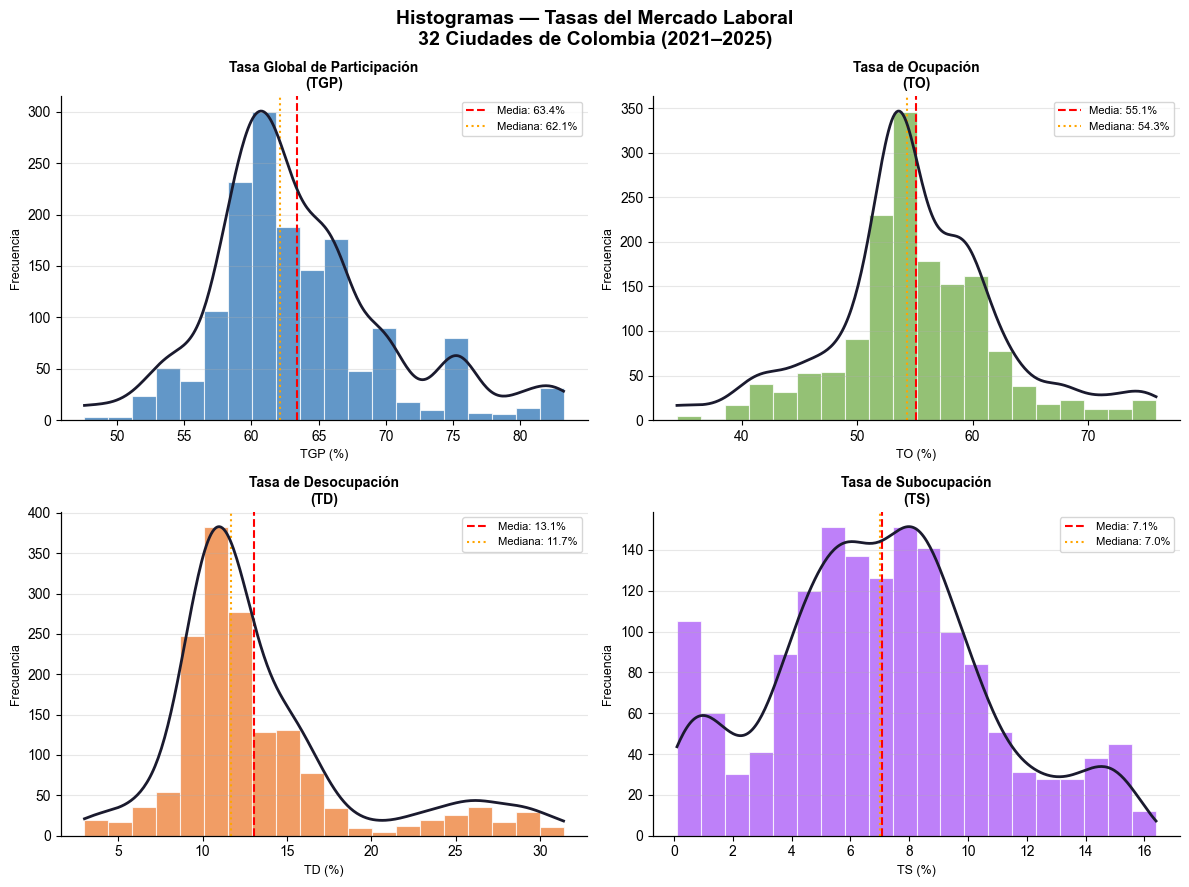

Figura 1: Histogramas


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Histogramas — Tasas del Mercado Laboral\n32 Ciudades de Colombia (2021–2025)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (tasa, abr, color) in enumerate(zip(TASAS, ABREV, COLORES)):
    ax = axes[i]
    data = df[tasa].dropna()

    # Histograma
    ax.hist(data, bins=20, color=color, alpha=0.75, edgecolor='white', linewidth=0.8)

    # Curva de densidad (KDE) en eje secundario para no distorsionar la escala
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = stats.gaussian_kde(data)
    ax2   = ax.twinx()
    ax2.plot(kde_x, kde(kde_x), color='#1a1a2e', linewidth=2)
    ax2.set_yticks([])

    # Líneas de media y mediana
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.1f}%')
    ax.axvline(data.median(), color='orange', linestyle=':',  linewidth=1.5, label=f'Mediana: {data.median():.1f}%')

    ax.set_title(tasa.replace(' (', '\n('), fontsize=10, fontweight='bold')
    ax.set_xlabel(f'{abr} (%)', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('histogramas.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figura 1: Histogramas')

---
## CELDA 5 — Boxplot
El boxplot muestra mediana, cuartiles y valores atípicos en una sola figura comparativa.

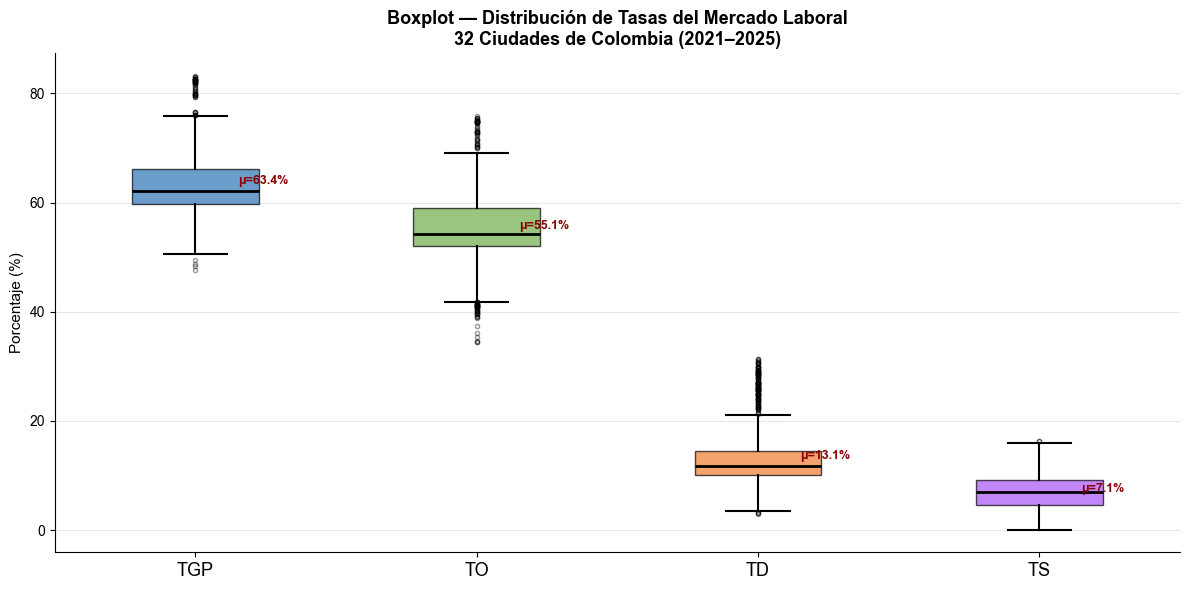

 Figura 2: Boxplot


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

# Preparamos los datos como lista de arrays
data_box = [df[t].dropna().values for t in TASAS]

# Dibujamos el boxplot con estilo personalizado
bp = ax.boxplot(
    data_box,
    patch_artist=True,          # rellena las cajas con color
    notch=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)  # outliers como puntos
)

# Aplicamos colores a cada caja
for patch, color in zip(bp['boxes'], COLORES):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(ABREV, fontsize=13)
ax.set_ylabel('Porcentaje (%)', fontsize=11)
ax.set_title('Boxplot — Distribución de Tasas del Mercado Laboral\n32 Ciudades de Colombia (2021–2025)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Anotamos la media de cada variable
for i, tasa in enumerate(TASAS, 1):
    media = df[tasa].mean()
    ax.annotate(f'μ={media:.1f}%', xy=(i, media), xytext=(i + 0.15, media),
                fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(' Figura 2: Boxplot')

---
## CELDA 6 — Diagramas de barras por ciudad
Comparamos las tasas promedio de cada una de las 32 ciudades.

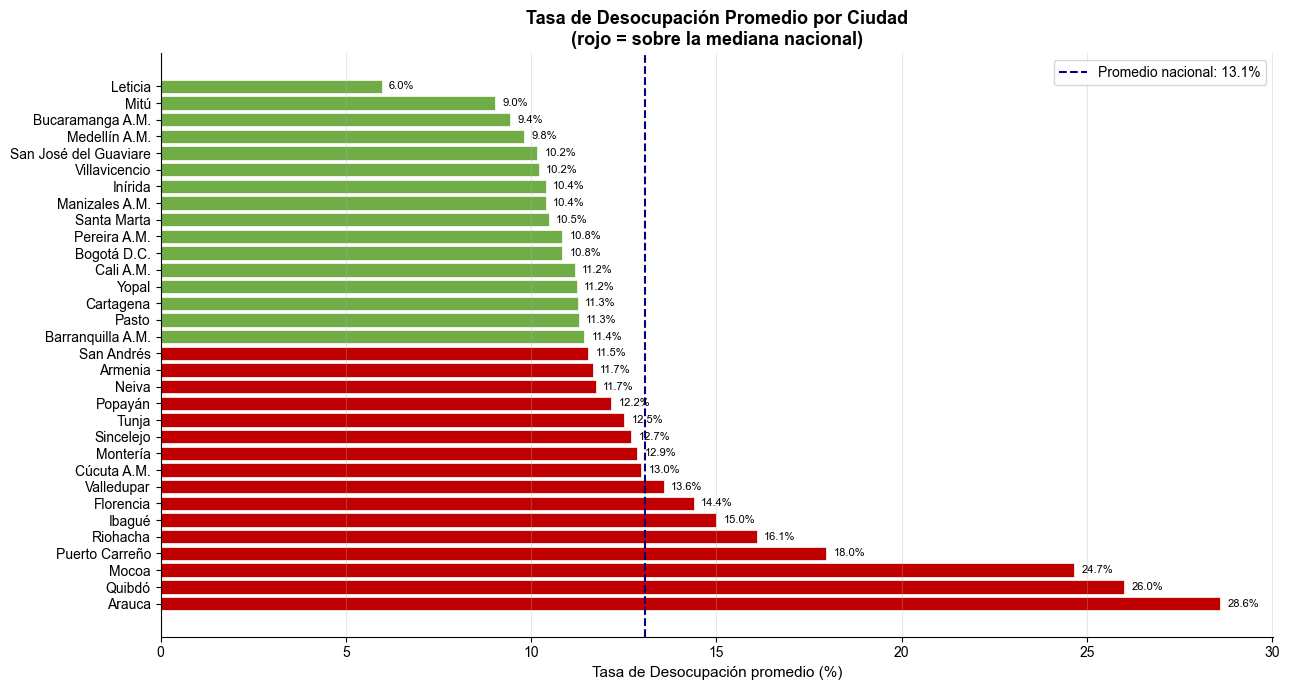

 Figura 3: Barras TD por ciudad


In [15]:
# ── Barras: Tasa de Desocupación por ciudad ────────────────────────────────
td_ciudad = df.groupby('Ciudad')['Tasa de Desocupación (TD)'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))

# Coloreamos diferente las ciudades sobre y bajo la mediana
bar_colors = ['#C00000' if v > td_ciudad.median() else '#70AD47' for v in td_ciudad.values]
bars = ax.barh(td_ciudad.index, td_ciudad.values, color=bar_colors, edgecolor='white', linewidth=0.5)

# Línea del promedio nacional
ax.axvline(td_ciudad.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Promedio nacional: {td_ciudad.mean():.1f}%')

ax.set_xlabel('Tasa de Desocupación promedio (%)', fontsize=11)
ax.set_title('Tasa de Desocupación Promedio por Ciudad\n(rojo = sobre la mediana nacional)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Etiquetas al final de cada barra
for bar, val in zip(bars, td_ciudad.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('barras_TD.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(' Figura 3: Barras TD por ciudad')

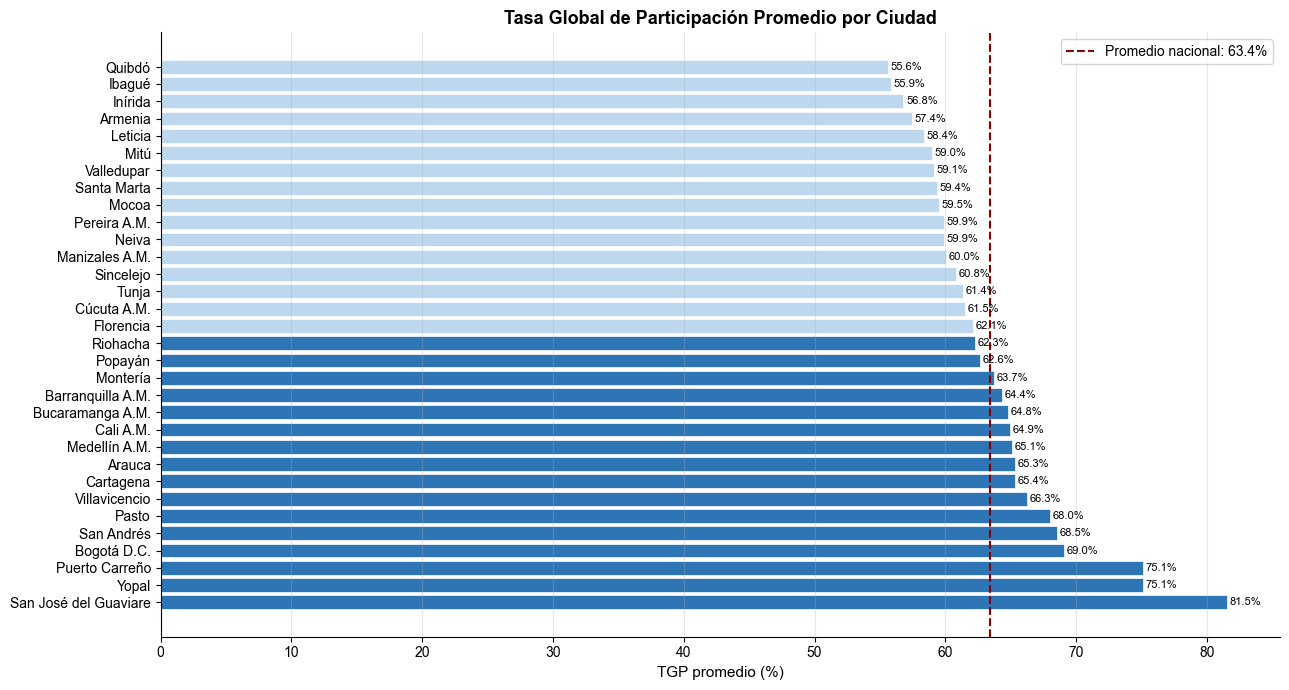

 Figura 4: Barras TGP por ciudad


In [16]:
# ── Barras: TGP por ciudad ─────────────────────────────────────────────────
tgp_ciudad = df.groupby('Ciudad')['Tasa Global de Participación (TGP)'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
bar_colors2 = ['#2E75B6' if v > tgp_ciudad.median() else '#BDD7EE' for v in tgp_ciudad.values]
bars2 = ax.barh(tgp_ciudad.index, tgp_ciudad.values, color=bar_colors2, edgecolor='white', linewidth=0.5)

ax.axvline(tgp_ciudad.mean(), color='darkred', linestyle='--', linewidth=1.5,
           label=f'Promedio nacional: {tgp_ciudad.mean():.1f}%')
ax.set_xlabel('TGP promedio (%)', fontsize=11)
ax.set_title('Tasa Global de Participación Promedio por Ciudad', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars2, tgp_ciudad.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('barras_TGP.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(' Figura 4: Barras TGP por ciudad')

---
## CELDA 7 — Serie de tiempo
Evolucion temporal del promedio nacional de las 4 tasas a lo largo de los 49 periodos.

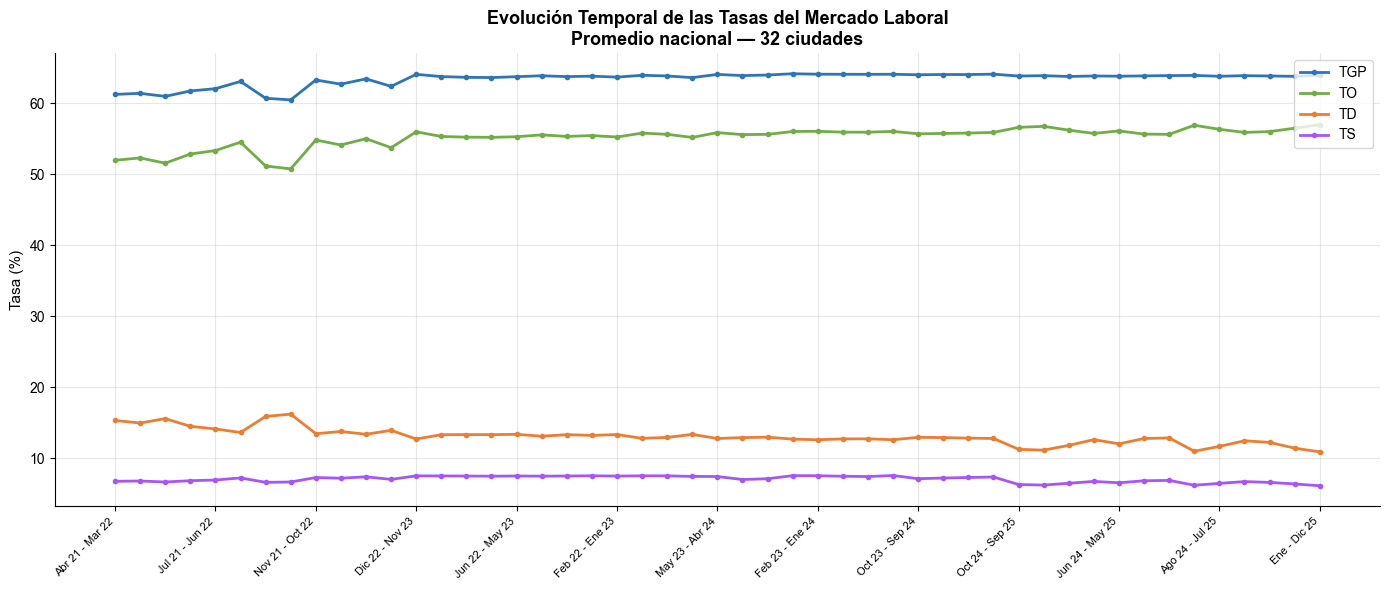

Figura 5: Serie de tiempo


In [17]:
# Extraer año de inicio para ordenar cronológicamente
def extraer_año(p):
    nums = re.findall(r'\d{2}', str(p))
    return int('20' + nums[-2]) if len(nums) >= 2 else int('20' + nums[0]) if nums else None

df['año_inicio'] = df['periodo del tiempo'].apply(extraer_año)

# Promedio nacional por periodo
df_sorted = df.sort_values('año_inicio')
df_nac = df_sorted.groupby('periodo del tiempo')[TASAS].mean().reset_index()
orden_map = df_sorted.drop_duplicates('periodo del tiempo').set_index('periodo del tiempo')['año_inicio']
df_nac['orden'] = df_nac['periodo del tiempo'].map(orden_map)
df_nac = df_nac.sort_values('orden').reset_index(drop=True)

# Graficar
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(df_nac))

for tasa, color, abr in zip(TASAS, COLORES, ABREV):
    ax.plot(x, df_nac[tasa], color=color, linewidth=2, label=abr, marker='o', markersize=3)

# Etiquetas del eje X (mostramos cada ~5 periodos para no saturar)
step = max(1, len(df_nac) // 10)
ax.set_xticks(list(range(0, len(df_nac), step)))
ax.set_xticklabels([df_nac['periodo del tiempo'].iloc[i] for i in range(0, len(df_nac), step)],
                   rotation=45, ha='right', fontsize=8)

ax.set_ylabel('Tasa (%)', fontsize=11)
ax.set_title('Evolución Temporal de las Tasas del Mercado Laboral\nPromedio nacional — 32 ciudades',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('serie_tiempo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figura 5: Serie de tiempo')

---
## CELDA 8 — Tabla completa de medidas estadísticas
Imprimimos todas las medidas de tendencia central y dispersión de forma organizada.

In [18]:
print('=' * 65)
print('  MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN — TODAS LAS TASAS')
print('=' * 65)

for tasa, abr in zip(TASAS, ABREV):
    s = df[tasa]
    q1, q2, q3 = s.quantile(0.25), s.quantile(0.50), s.quantile(0.75)
    print(f'\n  {abr} — {tasa}')
    print(f'  {"─"*55}')
    print(f'  Media:               {s.mean():.2f}%')
    print(f'  Mediana (Q2):        {s.median():.2f}%')
    print(f'  Moda:                {s.mode()[0]:.1f}%')
    print(f'  Varianza:            {s.var():.2f}')
    print(f'  Desviación estándar: {s.std():.2f} pp')
    print(f'  Mínimo:              {s.min():.1f}%')
    print(f'  Q1 (percentil 25):   {q1:.2f}%')
    print(f'  Q2 (mediana):        {q2:.2f}%')
    print(f'  Q3 (percentil 75):   {q3:.2f}%')
    print(f'  Máximo:              {s.max():.1f}%')
    print(f'  IQR (Q3 - Q1):       {q3 - q1:.2f} pp')
    print(f'  Asimetría (skew):    {s.skew():.3f}')

print(f'\n  N total de observaciones: {len(df):,}')
print(f'  Ciudades: {df["Ciudad"].nunique()} | Periodos: {df["periodo del tiempo"].nunique()}')

  MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN — TODAS LAS TASAS

  TGP — Tasa Global de Participación (TGP)
  ───────────────────────────────────────────────────────
  Media:               63.40%
  Mediana (Q2):        62.10%
  Moda:                60.2%
  Varianza:            37.02
  Desviación estándar: 6.08 pp
  Mínimo:              47.6%
  Q1 (percentil 25):   59.70%
  Q2 (mediana):        62.10%
  Q3 (percentil 75):   66.20%
  Máximo:              83.2%
  IQR (Q3 - Q1):       6.50 pp
  Asimetría (skew):    0.960

  TO — Tasa de Ocupación (TO)
  ───────────────────────────────────────────────────────
  Media:               55.14%
  Mediana (Q2):        54.30%
  Moda:                53.5%
  Varianza:            41.82
  Desviación estándar: 6.47 pp
  Mínimo:              34.4%
  Q1 (percentil 25):   52.10%
  Q2 (mediana):        54.30%
  Q3 (percentil 75):   59.00%
  Máximo:              75.9%
  IQR (Q3 - Q1):       6.90 pp
  Asimetría (skew):    0.285

  TD — Tasa de Desocupación (TD)